# Phân tích khách hàng — EDA chuyên sâu & Insight kinh doanh

**Bối cảnh:** Data Scientist tại một doanh nghiệp Fintech/E-commerce đang đối mặt ba vấn đề tăng trưởng:

1. **CAC (chi phí thu hút khách hàng mới) đang tăng**
2. **Churn cao, tập trung ở nhóm khách hàng giá trị**
3. **Chiến dịch giữ chân khách hàng bị mass-marketing** — gửi đại trà cho mọi khách hàng bất kể mức độ rủi ro hay giá trị, vừa lãng phí ngân sách cho người chắc chắn ở lại (hoặc chắc chắn rời đi) dù có can thiệp hay không, vừa gây phiền hà cho phần còn lại, ảnh hưởng trải nghiệm thương hiệu

**Mục tiêu dự án:** xác định **top 20% khách hàng ưu tiên** để can thiệp, nhằm tối đa hoá tỷ lệ giữ chân và hiệu quả (ROI) của ngân sách marketing.

Notebook này là lớp phân tích đặt nền móng cho mục tiêu đó bằng dữ liệu thật — phân khúc khách hàng, mức độ tập trung giá trị, và các quy luật vận hành — trước khi xây bất kỳ mô hình nào. Đây chính là phần "phân tích dữ liệu & insight": *phân tích dữ liệu lớn để tìm xu hướng, quy luật, cơ hội; đưa ra insight hỗ trợ phân khúc khách hàng, hiệu suất sản phẩm, và hiệu quả vận hành.*

Mô hình dự đoán hành động dựa trên các insight này, cùng phần mô phỏng chiến dịch gắn với ROI, nằm ở [`02_propensity_targeting_campaign.ipynb`](02_propensity_targeting_campaign.ipynb). Phương pháp luận của mô hình được tài liệu hoá tại [`../docs/model_card_churn.md`](../docs/model_card_churn.md).

**Dữ liệu:** `data/customers.csv` (ngày đăng ký, thời gian còn hoạt động) và `data/transactions.csv` (ngày, số tiền) — dữ liệu giao dịch một loại sản phẩm, liên tục tăng qua pipeline mô phỏng Airflow của dự án (xem [`README.md`](../README.md)).


In [1]:
%matplotlib inline
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from src.feature_engineering import build_churn_labels

plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

customers = pd.read_csv("../data/customers.csv", index_col=0)
transactions = pd.read_csv("../data/transactions.csv", index_col=0)
customers["signup_date"] = pd.to_datetime(customers["signup_date"])
transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])

print(f"Số khách hàng:       {len(customers):,}")
print(f"Số giao dịch:        {len(transactions):,}")
print(f"Khoảng thời gian:    {transactions['transaction_date'].min().date()} -> {transactions['transaction_date'].max().date()}")
print(f"Tổng doanh thu:      {transactions['amount'].sum():,.0f} đ")


Số khách hàng:       4,533
Số giao dịch:        72,238
Khoảng thời gian:    2025-01-03 -> 2026-07-11
Tổng doanh thu:      4,219,392 đ


## 1. Chất lượng & tổng quan dữ liệu

Kiểm tra sơ bộ trước khi tổng hợp — cùng mức độ chặt chẽ mà hệ thống production áp dụng khi nạp dữ liệu (`src/schemas.py` kiểm tra từng dòng dữ liệu thô theo một khuôn mẫu cố định).

In [2]:
quality = pd.DataFrame({
    "Khách hàng": [customers.isna().sum().sum(), customers.duplicated().sum(), customers["customer_id"].duplicated().sum()],
    "Giao dịch": [transactions.isna().sum().sum(), transactions.duplicated().sum(), np.nan],
}, index=["Ô trống (null)", "Dòng trùng lặp", "customer_id trùng lặp"])
display(quality)

txns_per_customer = transactions.groupby("customer_id").size()
customers_without_txns = customers.loc[~customers["customer_id"].isin(transactions["customer_id"])]
print(f"Khách hàng chưa từng giao dịch: {len(customers_without_txns):,} ({len(customers_without_txns)/len(customers):.1%} tổng số khách hàng)")
print(f"Số giao dịch/khách hàng — trung bình: {txns_per_customer.mean():.1f}, trung vị: {txns_per_customer.median():.0f}, "
      f"p95: {txns_per_customer.quantile(0.95):.0f}, cao nhất: {txns_per_customer.max():.0f}")
print(f"Giá trị giao dịch — trung bình: {transactions['amount'].mean():.2f} đ, trung vị: {transactions['amount'].median():.2f} đ, "
      f"p95: {transactions['amount'].quantile(0.95):.2f} đ")


,Khách hàng,Giao dịch
Ô trống (null),0,0.00
Dòng trùng lặp,0,0.00
customer_id trùng lặp,0,NaN


Khách hàng chưa từng giao dịch: 1,193 (26.3% tổng số khách hàng)
Số giao dịch/khách hàng — trung bình: 21.6, trung vị: 13, p95: 71, cao nhất: 233
Giá trị giao dịch — trung bình: 58.41 đ, trung vị: 41.01 đ, p95: 171.69 đ


## 2. Tăng trưởng & hiệu quả thu hút khách hàng (Vấn đề #1 — CAC tăng)

Không có dữ liệu chi phí marketing thật nên không thể tính CAC chính xác — nói rõ điều này thay vì "chế" ra một con số. Điều dữ liệu giao dịch *có thể* cho thấy là một chỉ số đại diện quan trọng cho câu chuyện CAC: **mỗi lứa khách hàng mới có thực sự tạo ra doanh thu hay không**, hay doanh nghiệp đang thu hút ngày càng nhiều khách hàng nhưng doanh thu ban đầu lại chững/giảm?

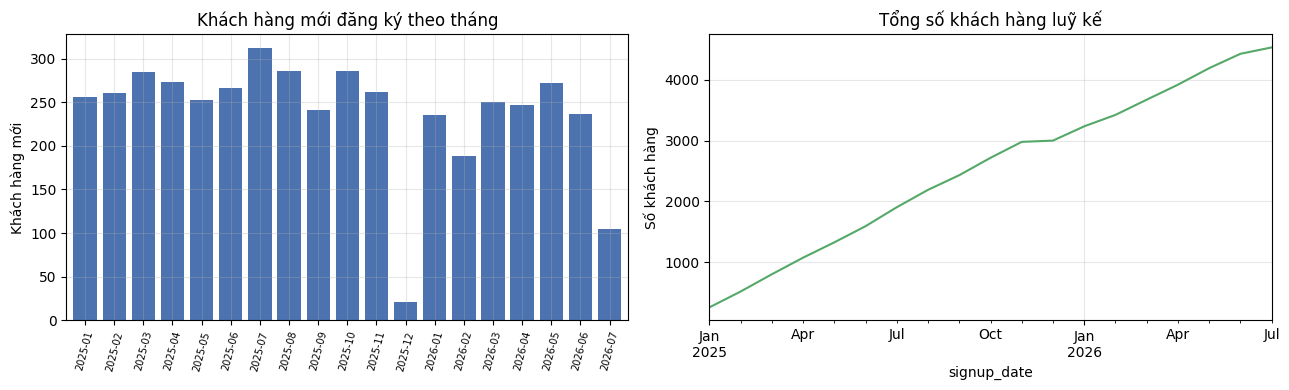

In [3]:
signups_by_month = customers.set_index("signup_date").resample("MS").size()
cumulative_customers = signups_by_month.cumsum()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
signups_by_month.plot(ax=axes[0], kind="bar", color="#4C72B0", width=0.8)
axes[0].set_title("Khách hàng mới đăng ký theo tháng")
axes[0].set_xlabel("")
axes[0].set_ylabel("Khách hàng mới")
axes[0].set_xticklabels([d.strftime("%Y-%m") for d in signups_by_month.index], rotation=75, fontsize=7)

cumulative_customers.plot(ax=axes[1], color="#55A868")
axes[1].set_title("Tổng số khách hàng luỹ kế")
axes[1].set_ylabel("Số khách hàng")
plt.tight_layout()
plt.show()


Đã loại 3 nhóm tháng gần nhất vì chưa đủ 90 ngày quan sát.


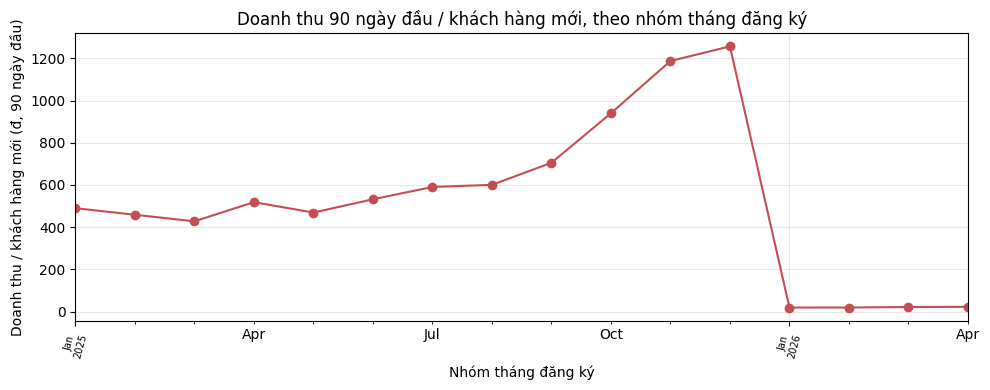

Doanh thu 90 ngày đầu/khách — trung bình 3 nhóm sớm nhất: 458.91 đ, trung bình 3 nhóm gần nhất: 21.22 đ


In [4]:
# Chỉ số đại diện hiệu quả thu hút khách: doanh thu 90 ngày đầu/khách hàng, theo nhóm tháng đăng ký
max_date = transactions["transaction_date"].max()
customers["cohort"] = customers["signup_date"].dt.to_period("M")
txn_c = transactions.merge(customers[["customer_id", "signup_date", "cohort"]], on="customer_id")
txn_c["days_since_signup"] = (txn_c["transaction_date"] - txn_c["signup_date"]).dt.days
first_90d = txn_c[(txn_c["days_since_signup"] >= 0) & (txn_c["days_since_signup"] <= 90)]

cohort_rev = first_90d.groupby("cohort")["amount"].sum()
cohort_size = customers.groupby("cohort")["customer_id"].size()
cohort_rev_per_customer = (cohort_rev / cohort_size).dropna().sort_index()

# Kỷ luật point-in-time: một nhóm khách mới đăng ký trong 90 ngày gần nhất
# chưa đủ thời gian quan sát trọn vẹn — nếu tính vào sẽ cho ra "doanh thu/khách
# hàng" thấp giả tạo (do chưa đủ ngày), không phải tín hiệu thật về hiệu quả
# thu hút khách. Cùng nguyên tắc mà pipeline mô hình áp dụng cho feature
# (xem src/feature_engineering.py), áp dụng ở đây cho EDA.
complete_cutoff = (max_date - pd.Timedelta(days=90)).to_period("M")
n_censored_cohorts = (cohort_rev_per_customer.index > complete_cutoff).sum()
cohort_rev_per_customer = cohort_rev_per_customer[cohort_rev_per_customer.index <= complete_cutoff]
cohort_rev_per_customer.index = cohort_rev_per_customer.index.to_timestamp()
print(f"Đã loại {n_censored_cohorts} nhóm tháng gần nhất vì chưa đủ 90 ngày quan sát.")

fig, ax = plt.subplots(figsize=(10, 4))
cohort_rev_per_customer.plot(ax=ax, marker="o", color="#C44E52")
ax.set_title("Doanh thu 90 ngày đầu / khách hàng mới, theo nhóm tháng đăng ký")
ax.set_ylabel("Doanh thu / khách hàng mới (đ, 90 ngày đầu)")
ax.set_xlabel("Nhóm tháng đăng ký")
plt.xticks(rotation=75, fontsize=7)
plt.tight_layout()
plt.show()

print(f"Doanh thu 90 ngày đầu/khách — trung bình 3 nhóm sớm nhất: {cohort_rev_per_customer.head(3).mean():.2f} đ, "
      f"trung bình 3 nhóm gần nhất: {cohort_rev_per_customer.tail(3).mean():.2f} đ")


**Đọc chỉ số này cho câu chuyện CAC:** nếu doanh thu 90 ngày đầu/khách hàng mới đi ngang hoặc giảm dần ở các nhóm gần đây trong khi tổng số khách hàng vẫn tăng, thì mỗi đồng chi cho thu hút khách đang mua về một khách hàng *kém sinh lời hơn* trước — đây chính là lý do CAC tăng thực sự nguy hiểm, không chỉ đơn thuần là bài toán chi phí. Chỉ số này nên được đặt cạnh một con số CAC thật khi có dữ liệu chi tiêu; ngay cả khi chưa có, nó đã cho biết tăng trưởng hiện tại có "khoẻ mạnh" hay không.

## 3. Xu hướng doanh thu & giao dịch

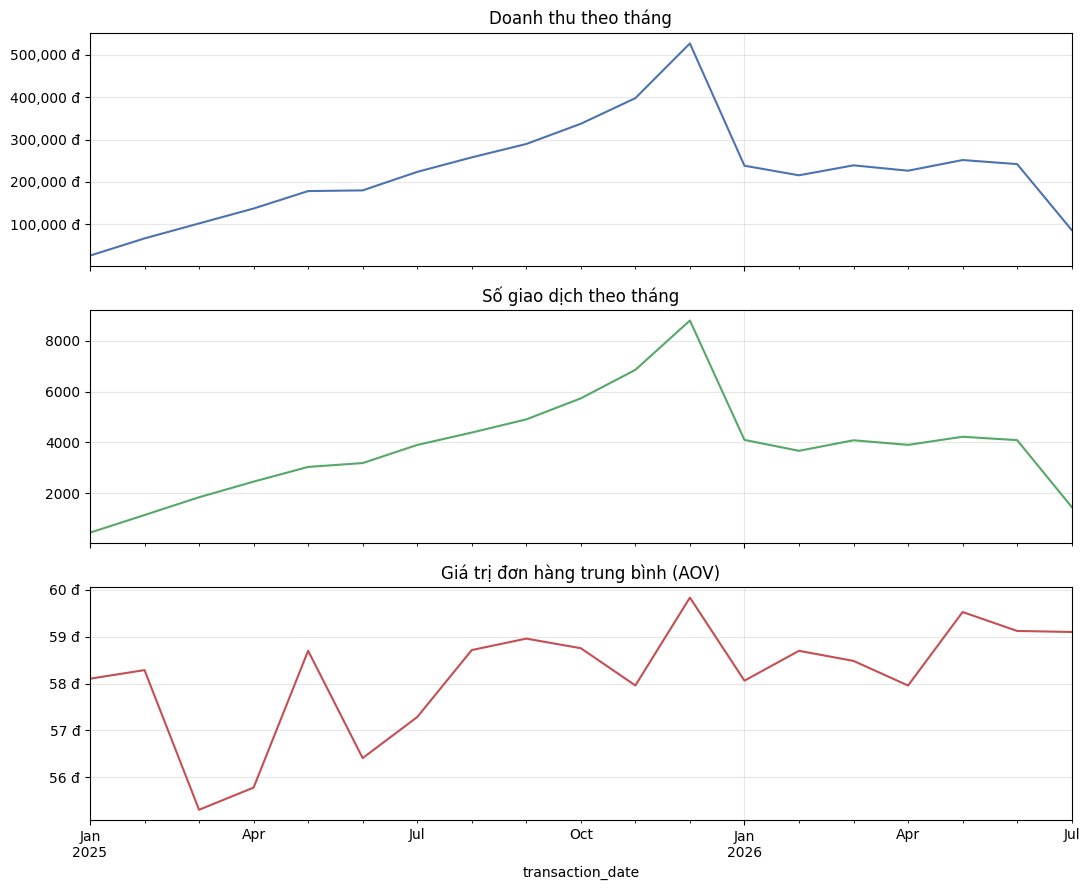

In [5]:
monthly = transactions.set_index("transaction_date").resample("MS").agg(
    revenue=("amount", "sum"), n_txns=("amount", "size")
)
monthly["aov"] = monthly["revenue"] / monthly["n_txns"]

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
monthly["revenue"].plot(ax=axes[0], color="#4C72B0")
axes[0].set_title("Doanh thu theo tháng")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f} đ"))

monthly["n_txns"].plot(ax=axes[1], color="#55A868")
axes[1].set_title("Số giao dịch theo tháng")

monthly["aov"].plot(ax=axes[2], color="#C44E52")
axes[2].set_title("Giá trị đơn hàng trung bình (AOV)")
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f} đ"))
plt.tight_layout()
plt.show()


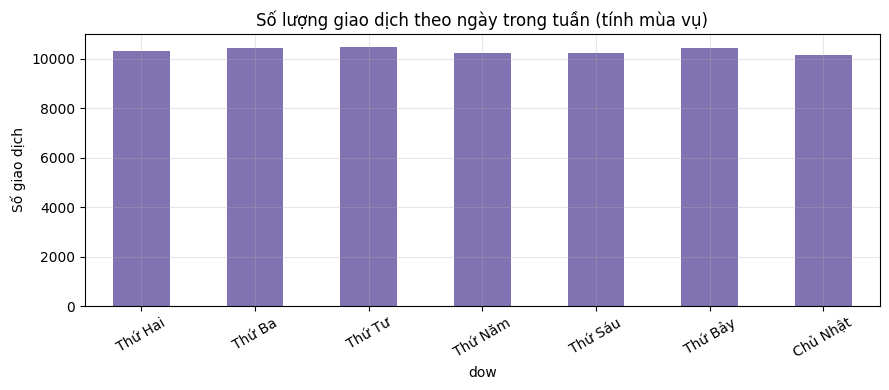

In [6]:
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_vn = {"Monday": "Thứ Hai", "Tuesday": "Thứ Ba", "Wednesday": "Thứ Tư", "Thursday": "Thứ Năm",
          "Friday": "Thứ Sáu", "Saturday": "Thứ Bảy", "Sunday": "Chủ Nhật"}
by_dow = transactions.assign(dow=transactions["transaction_date"].dt.day_name()).groupby("dow").agg(
    n_txns=("amount", "size"), revenue=("amount", "sum")
).reindex(dow_order)
by_dow.index = by_dow.index.map(dow_vn)

fig, ax = plt.subplots(figsize=(9, 4))
by_dow["n_txns"].plot(ax=ax, kind="bar", color="#8172B2")
ax.set_title("Số lượng giao dịch theo ngày trong tuần (tính mùa vụ)")
ax.set_ylabel("Số giao dịch")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## 4. Mức độ tập trung giá trị khách hàng (Vấn đề #2 — "khách hàng giá trị")

Trước khi nhắm tới "khách hàng giá trị," cần đo xem giá trị đang tập trung tới mức nào. Đường cong Lorenz / phân tích Pareto trả lời câu hỏi: *bao nhiêu % khách hàng tạo ra bao nhiêu % doanh thu?*

/var/folders/pp/ynfzr7yx2mz8y_75j6hfpwt80000gn/T/ipykernel_38103/817892354.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  gini = 1 - 2 * np.trapz(cum_rev_share, cum_cust_share)


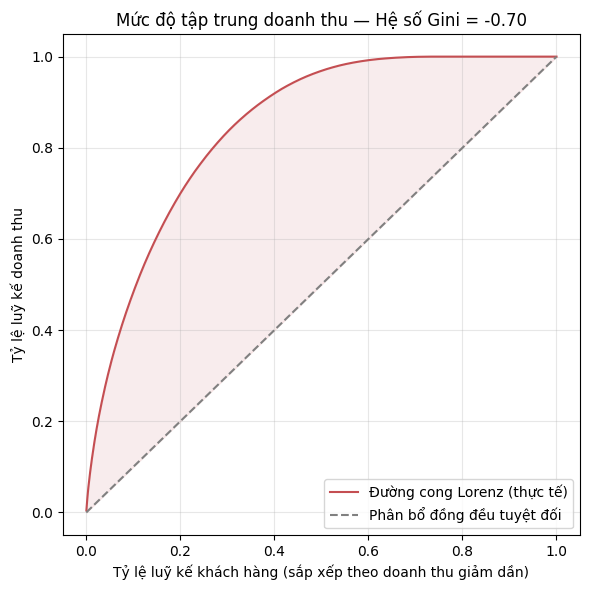

Top 10% khách hàng tạo ra 48.3% tổng doanh thu
Top 20% khách hàng tạo ra 70.0% tổng doanh thu
Top 50% khách hàng tạo ra 96.9% tổng doanh thu


In [7]:
cust_revenue = transactions.groupby("customer_id")["amount"].sum().reindex(customers["customer_id"]).fillna(0.0)
sorted_rev = cust_revenue.sort_values(ascending=False).values
cum_rev_share = np.cumsum(sorted_rev) / sorted_rev.sum()
cum_cust_share = np.arange(1, len(sorted_rev) + 1) / len(sorted_rev)

def revenue_share_at(top_pct):
    k = int(len(sorted_rev) * top_pct)
    return sorted_rev[:k].sum() / sorted_rev.sum()

# Hệ số Gini: đo mức độ chênh lệch — 0 = chia đều tuyệt đối, 1 = một người giữ hết
gini = 1 - 2 * np.trapz(cum_rev_share, cum_cust_share)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(cum_cust_share, cum_rev_share, color="#C44E52", label="Đường cong Lorenz (thực tế)")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Phân bổ đồng đều tuyệt đối")
ax.fill_between(cum_cust_share, cum_rev_share, cum_cust_share, alpha=0.1, color="#C44E52")
ax.set_xlabel("Tỷ lệ luỹ kế khách hàng (sắp xếp theo doanh thu giảm dần)")
ax.set_ylabel("Tỷ lệ luỹ kế doanh thu")
ax.set_title(f"Mức độ tập trung doanh thu — Hệ số Gini = {gini:.2f}")
ax.legend()
plt.tight_layout()
plt.show()

for p in [0.10, 0.20, 0.50]:
    print(f"Top {p:.0%} khách hàng tạo ra {revenue_share_at(p):.1%} tổng doanh thu")


Đây là cơ sở định lượng cho khái niệm "khách hàng giá trị" trong bài toán kinh doanh: giá trị đang tập trung, không chia đều — nên một chương trình chống churn đối xử với mọi khách hàng như nhau, xét về bản chất, đang phân bổ nguồn lực sai chỗ so với nơi doanh thu thực sự nằm.

## 5. Phân tích sâu phân khúc RFM

Chấm điểm Recency/Frequency/Monetary theo quantile, gắn với tên phân khúc dễ hiểu — cách tiếp cận phân khúc khách hàng chuẩn, mở rộng thêm tỷ trọng doanh thu theo từng phân khúc để không nhầm lẫn "quy mô phân khúc" với "giá trị phân khúc".

In [8]:
snapshot_date = transactions["transaction_date"].max() + pd.Timedelta(days=1)

rfm = transactions.groupby("customer_id").agg(
    recency=("transaction_date", lambda s: (snapshot_date - s.max()).days),
    frequency=("amount", "size"),
    monetary=("amount", "sum"),
)
rfm = rfm.reindex(customers["customer_id"]).fillna({"recency": 999, "frequency": 0, "monetary": 0.0})

rfm["R_score"] = pd.qcut(rfm["recency"].rank(method="first"), 4, labels=[4, 3, 2, 1]).astype(int)   # recency thấp = tốt = điểm cao
rfm["F_score"] = pd.qcut(rfm["frequency"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)
rfm["M_score"] = pd.qcut(rfm["monetary"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)
rfm["RFM_sum"] = rfm[["R_score", "F_score", "M_score"]].sum(axis=1)

def segment(row):
    r, f, m = row["R_score"], row["F_score"], row["M_score"]
    if r >= 3 and f >= 3 and m >= 3:
        return "Khách hàng VIP"
    if r >= 3 and f >= 2:
        return "Khách hàng trung thành"
    if r >= 3 and f <= 2:
        return "Khách hàng mới / tiềm năng"
    if r == 2 and f >= 2:
        return "Có nguy cơ rời bỏ"
    if r <= 2 and f >= 3 and m >= 3:
        return "Giá trị cao - Nguy cơ rời bỏ"
    if r <= 2 and f <= 2:
        return "Không hoạt động"
    return "Khác"

rfm["segment"] = rfm.apply(segment, axis=1)

segment_profile = rfm.groupby("segment").agg(
    n_customers=("segment", "size"), total_revenue=("monetary", "sum"),
    avg_recency=("recency", "mean"), avg_frequency=("frequency", "mean"),
).sort_values("total_revenue", ascending=False)
segment_profile["pct_customers"] = segment_profile["n_customers"] / segment_profile["n_customers"].sum()
segment_profile["pct_revenue"] = segment_profile["total_revenue"] / segment_profile["total_revenue"].sum()

segment_profile_vn = segment_profile.rename(columns={
    "n_customers": "Số khách hàng", "total_revenue": "Tổng doanh thu",
    "avg_recency": "Số ngày từ lần mua gần nhất (TB)", "avg_frequency": "Số lần mua (TB)",
    "pct_customers": "% khách hàng", "pct_revenue": "% doanh thu",
})
display(segment_profile_vn.style.format({"% khách hàng": "{:.1%}", "% doanh thu": "{:.1%}", "Tổng doanh thu": "{:,.0f} đ"}))


,Số khách hàng,Tổng doanh thu,Số ngày từ lần mua gần nhất (TB),Số lần mua (TB),% khách hàng,% doanh thu
segment,,,,,,
Khách hàng VIP,1878,"3,805,538 đ",17.174121,34.536741,41.4%,90.2%
Có nguy cơ rời bỏ,1073,"342,503 đ",167.304753,5.381174,23.7%,8.1%
Khách hàng trung thành,389,"71,351 đ",26.825193,4.123393,8.6%,1.7%
Không hoạt động,1193,0 đ,999.000000,0.000000,26.3%,0.0%


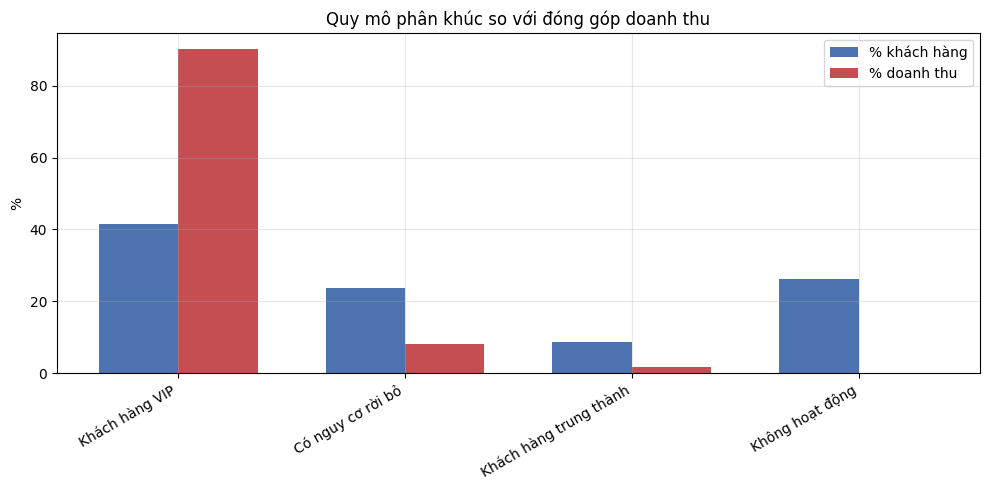

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
order = segment_profile.index
x = np.arange(len(order))
width = 0.35
ax.bar(x - width/2, segment_profile["pct_customers"] * 100, width, label="% khách hàng", color="#4C72B0")
ax.bar(x + width/2, segment_profile["pct_revenue"] * 100, width, label="% doanh thu", color="#C44E52")
ax.set_xticks(x)
ax.set_xticklabels(order, rotation=30, ha="right")
ax.set_ylabel("%")
ax.set_title("Quy mô phân khúc so với đóng góp doanh thu")
ax.legend()
plt.tight_layout()
plt.show()


**Phân khúc quan trọng nhất cho vấn đề #2** là `Giá trị cao - Nguy cơ rời bỏ`: khách hàng có tần suất và giá trị mua sắm lịch sử tốt nhưng đã lâu không quay lại. Họ vừa có giá trị cao (điểm M/F cao) vừa có nguy cơ rời bỏ (điểm R thấp) — chính là nhóm mà một chiến dịch mass-marketing dễ bỏ sót nhất (bị chìm giữa các khách "có nguy cơ" giá trị thấp) hoặc tiếp cận quá trễ.

## 6. Định lượng lãng phí của mass-marketing (Vấn đề #3)

Định lượng trực tiếp vấn đề đã nêu trong bài toán kinh doanh: *"Gửi voucher cho người chắc chắn đi hoặc người chắc chắn ở lại"*. Dùng cửa sổ 30 ngày hướng về tương lai (giống định nghĩa nhãn churn của mô hình — xem [`docs/model_card_churn.md`](../docs/model_card_churn.md)), có thể phân loại toàn bộ khách hàng vào các nhóm mà một chiến dịch đại trà không phân biệt được, nhưng một chiến dịch có nhắm mục tiêu thì có thể.

In [10]:
INACTIVITY_WINDOW = 30
label_snapshot = transactions["transaction_date"].max() - pd.Timedelta(days=INACTIVITY_WINDOW)
labels = build_churn_labels(transactions, label_snapshot, INACTIVITY_WINDOW).set_index("customer_id")

waste = rfm.join(labels, how="left")
waste["churn"] = waste["churn"].fillna(1).astype(int)  # khách chưa có giao dịch trước snapshot: coi như đã ngưng hoạt động

def waste_bucket(row):
    if row["segment"] == "Khách hàng VIP" and row["churn"] == 0:
        return "Chắc chắn ở lại (VIP, giữ được dù không can thiệp)"
    if row["segment"] == "Không hoạt động":
        return "Khó phản hồi (không hoạt động đã lâu)"
    if "Nguy cơ rời bỏ" in row["segment"]:
        return "Cơ hội can thiệp thực sự (có nguy cơ rời bỏ)"
    return "Khác / chưa rõ"

waste["bucket"] = waste.apply(waste_bucket, axis=1)
bucket_summary = waste.groupby("bucket").agg(n_customers=("bucket", "size"), revenue=("monetary", "sum"))
bucket_summary["pct_customers"] = bucket_summary["n_customers"] / bucket_summary["n_customers"].sum()

bucket_summary_vn = bucket_summary.rename(columns={
    "n_customers": "Số khách hàng", "revenue": "Doanh thu", "pct_customers": "% khách hàng",
})
display(bucket_summary_vn.sort_values("% khách hàng", ascending=False).style.format(
    {"% khách hàng": "{:.1%}", "Doanh thu": "{:,.0f} đ"}
))

wasted_pct = bucket_summary.loc[bucket_summary.index.str.startswith(("Chắc chắn ở lại", "Khó phản hồi")), "pct_customers"].sum()
print(f"\nNếu chạy mass-marketing (tiếp cận 100% khách hàng), ước tính {wasted_pct:.1%} lượt tiếp cận "
      f"rơi vào nhóm chắc chắn ở lại hoặc rất khó phản hồi — ngân sách chi ra gần như không tạo thêm "
      f"hiệu quả, chưa kể chi phí gây phiền hà (over-treatment/spam) cho chính những khách hàng này.")


,Số khách hàng,Doanh thu,% khách hàng
bucket,,,
Khác / chưa rõ,1827,"852,977 đ",40.3%
"Chắc chắn ở lại (VIP, giữ được dù không can thiệp)",1513,"3,366,415 đ",33.4%
Khó phản hồi (không hoạt động đã lâu),1193,0 đ,26.3%



Nếu chạy mass-marketing (tiếp cận 100% khách hàng), ước tính 59.7% lượt tiếp cận rơi vào nhóm chắc chắn ở lại hoặc rất khó phản hồi — ngân sách chi ra gần như không tạo thêm hiệu quả, chưa kể chi phí gây phiền hà (over-treatment/spam) cho chính những khách hàng này.


## 7. Hiệu suất theo nhóm giá trị (thay cho phân tích hiệu suất sản phẩm)

> Bộ dữ liệu này không có chiều sản phẩm/danh mục — một quyết định phạm vi có chủ đích cho giai đoạn này (xem `../README.md`). "Hiệu suất sản phẩm" được diễn giải lại thành **hiệu suất theo nhóm mức chi tiêu**: cùng cách tiếp cận phân tích (nhóm nào đang tăng trưởng, nhóm nào đang giảm, nhóm nào chuyển đổi tốt nhất) áp dụng cho nhóm giá trị thay vì mã sản phẩm, dựa trên những gì dữ liệu thực sự có.

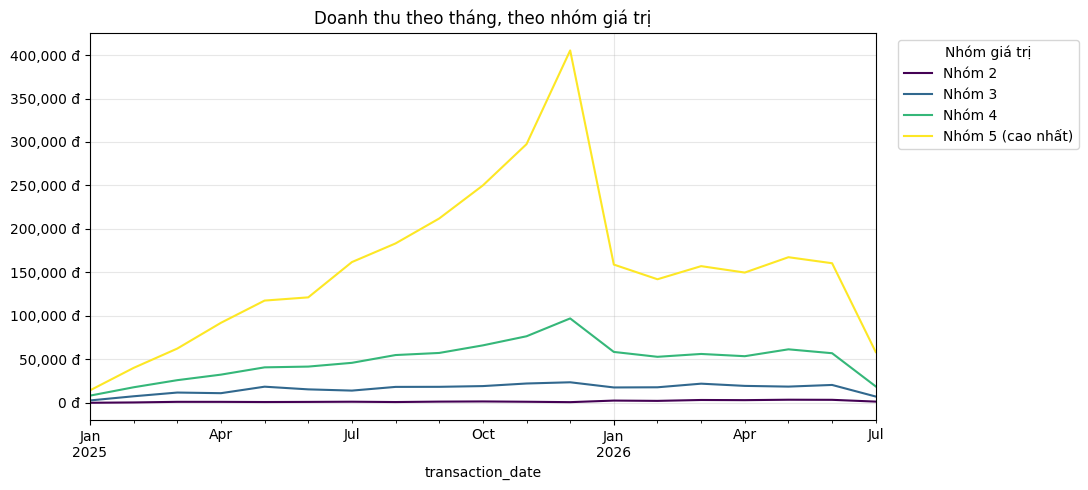

,Số khách hàng,Doanh thu,Giá trị đơn hàng TB,Doanh thu/khách hàng,Số giao dịch/khách hàng
tier,,,,,
Nhóm 2,620,"32,968 đ",32.87 đ,53 đ,1.6
Nhóm 3,907,"308,023 đ",44.76 đ,340 đ,7.6
Nhóm 4,906,"925,143 đ",51.77 đ,"1,021 đ",19.7
Nhóm 5 (cao nhất),907,"2,953,258 đ",63.53 đ,"3,256 đ",51.2


In [11]:
value_tiers = pd.qcut(cust_revenue.rank(method="first"), 5, labels=["Nhóm 1 (thấp nhất)", "Nhóm 2", "Nhóm 3", "Nhóm 4", "Nhóm 5 (cao nhất)"])
tier_df = pd.DataFrame({"customer_id": cust_revenue.index.to_numpy(), "tier": value_tiers.to_numpy(), "total_revenue": cust_revenue.to_numpy()})

tier_txns = transactions.merge(tier_df[["customer_id", "tier"]], on="customer_id")
tier_monthly = tier_txns.set_index("transaction_date").groupby([pd.Grouper(freq="MS"), "tier"], observed=True)["amount"].sum().unstack("tier")

fig, ax = plt.subplots(figsize=(11, 5))
tier_monthly.plot(ax=ax, colormap="viridis")
ax.set_title("Doanh thu theo tháng, theo nhóm giá trị")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f} đ"))
ax.legend(title="Nhóm giá trị", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

tier_summary = tier_txns.groupby("tier", observed=True).agg(
    n_customers=("customer_id", "nunique"), n_txns=("amount", "size"),
    revenue=("amount", "sum"), avg_order_value=("amount", "mean"),
)
tier_summary["revenue_per_customer"] = tier_summary["revenue"] / tier_summary["n_customers"]
tier_summary["txns_per_customer"] = tier_summary["n_txns"] / tier_summary["n_customers"]

tier_summary_vn = tier_summary.rename(columns={
    "n_customers": "Số khách hàng", "n_txns": "Số giao dịch", "revenue": "Doanh thu",
    "avg_order_value": "Giá trị đơn hàng TB", "revenue_per_customer": "Doanh thu/khách hàng",
    "txns_per_customer": "Số giao dịch/khách hàng",
})
display(tier_summary_vn[["Số khách hàng", "Doanh thu", "Giá trị đơn hàng TB", "Doanh thu/khách hàng", "Số giao dịch/khách hàng"]].style.format(
    {"Doanh thu": "{:,.0f} đ", "Giá trị đơn hàng TB": "{:.2f} đ", "Doanh thu/khách hàng": "{:,.0f} đ", "Số giao dịch/khách hàng": "{:.1f}"}
))


## 8. Insight về hiệu quả vận hành

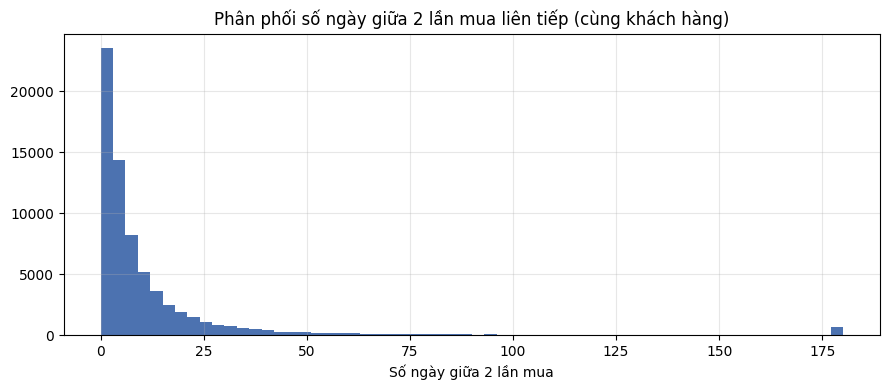

Khoảng cách giữa 2 lần mua — trung vị: 5 ngày, p90: 27 ngày, p99: 180 ngày
Mua lặp lại trong cùng ngày (khoảng cách = 0): 5,472 (7.94% tổng số cặp giao dịch liên tiếp) — nên kiểm tra chất lượng dữ liệu/gian lận nếu tỷ lệ này cao bất thường.


In [12]:
# Phân tích khoảng cách giữa các lần mua liên tiếp của cùng một khách hàng
txn_sorted = transactions.sort_values(["customer_id", "transaction_date"])
gap_days = txn_sorted.groupby("customer_id")["transaction_date"].diff().dt.days.dropna()

fig, ax = plt.subplots(figsize=(9, 4))
gap_days.clip(upper=gap_days.quantile(0.99)).hist(ax=ax, bins=60, color="#4C72B0")
ax.set_title("Phân phối số ngày giữa 2 lần mua liên tiếp (cùng khách hàng)")
ax.set_xlabel("Số ngày giữa 2 lần mua")
plt.tight_layout()
plt.show()

print(f"Khoảng cách giữa 2 lần mua — trung vị: {gap_days.median():.0f} ngày, p90: {gap_days.quantile(0.90):.0f} ngày, "
      f"p99: {gap_days.quantile(0.99):.0f} ngày")
print(f"Mua lặp lại trong cùng ngày (khoảng cách = 0): {(gap_days == 0).sum():,} "
      f"({(gap_days == 0).mean():.2%} tổng số cặp giao dịch liên tiếp) — nên kiểm tra chất lượng dữ liệu/gian lận "
      f"nếu tỷ lệ này cao bất thường.")


**Ý nghĩa vận hành của các con số trên:**
- Khối lượng giao dịch theo ngày trong tuần (mục 3) cho biết đội vận hành/hỗ trợ nên bố trí nhân sự thế nào — nếu năng lực hỗ trợ dàn đều cả tuần trong khi khối lượng giao dịch lệch hẳn về một số ngày, đó là điểm lệch pha đáng lưu ý.
- Đuôi phải của phân phối khoảng cách mua hàng chính là tín hiệu "thời điểm vàng" để kích hoạt lại khách hàng: khách thường mua mỗi ~30 ngày nhưng nay đã vượt mốc p90 là nhóm cần một "trigger theo số ngày không mua" bắt được *trước khi* họ rời bỏ hẳn — chính là feature recency mà mô hình dự đoán churn ở notebook tiếp theo sử dụng.
- Mức độ tập trung doanh thu (mục 4) đồng thời là một **rủi ro vận hành đối với nhóm khách hàng trọng yếu**: một số ít khách hàng nắm giữ tỷ trọng doanh thu không tương xứng, nên mất dù chỉ một người cũng ảnh hưởng đáng kể — một góc nhìn vận hành khác với bài toán bố trí nhân sự theo khối lượng, nhưng cùng dựa trên con số nói trên.

## 9. Tóm tắt insight

| Vấn đề kinh doanh | Dữ liệu cho thấy gì | Ở đâu |
|---|---|---|
| **#1 CAC tăng** | Doanh thu 90 ngày đầu/khách hàng mới là chỉ số đại diện cho hiệu quả thu hút khách khi chưa có dữ liệu chi tiêu thật — nhóm gần đây đi ngang/giảm là tín hiệu cảnh báo sớm, nên đặt cạnh một con số CAC thật trong tương lai. | Mục 2 |
| **#2 Churn ở nhóm khách hàng giá trị** | Doanh thu đang tập trung (hệ số Gini ở mục 4); phân khúc RFM `Giá trị cao - Nguy cơ rời bỏ` chính là nhóm vừa quan trọng về doanh thu vừa đang có dấu hiệu rời đi — mục tiêu ưu tiên cao nhất để can thiệp. | Mục 4, 5 |
| **#3 Mass-marketing lãng phí / gây phiền hà** | Một tỷ lệ đáng kể khách hàng rơi vào nhóm "chắc chắn ở lại" hoặc "khó phản hồi" mà một chiến dịch đại trà không thể phân biệt được — định lượng trực tiếp ở mục 6. | Mục 6 |

**Đây chính là lý do cần một mô hình nhắm mục tiêu (targeting model).** Phân khúc và mức độ tập trung giá trị cho biết *ai đáng để giữ chân*; phân tích lãng phí cho biết *vì sao mass-marketing không thể làm việc đó hiệu quả*. Notebook tiếp theo, [`02_propensity_targeting_campaign.ipynb`](02_propensity_targeting_campaign.ipynb), xây dựng mô hình dự đoán churn, kết hợp với ước lượng giá trị khách hàng thành một điểm ưu tiên duy nhất, và mô phỏng ROI khi chỉ nhắm vào top 20% thay vì toàn bộ khách hàng.